## NFL 4th Down Decision Analysis
#### Phase 2: Data Preparation & EDA

This notebook prepares and explores NFL 4th-down scenarios for a capstone project on decision-making under game context. The goals here are:

- Create a clean, labeled dataset of 4th-down decisions (punt, field goal, go for it).
- Engineer pre-snap game-context features (field position, score, time, timeouts).
- Perform exploratory analysis of decision frequencies and success/failure patterns.

In this analysis, a 4th‑down play is considered successful if the offense either converts for a new set of downs or gains points on the play (i.e., scored a touchdown or a made field goal).

Model training and evaluation will be done in a separate modeling notebook.

In [1]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
import xgboost as xgb
 


### 1. Locate and load data

In this section, I import the required libraries and load a preprocessed CSV of NFL 4th-down plays into a pandas DataFrame.


In [3]:

project_root = Path('/Users/macbook/Projects/data-science/nfl-4th-down-win-probability')
data_path = project_root / 'data' / 'processed' / 'fourth_down_scenarios_v2.csv'

if not data_path.exists():
    raise FileNotFoundError(f"Missing file: {data_path}")

raw_df = pd.read_csv(data_path)



### 2. Clean text + create labels

Here, I standardize key text fields and derive a 3-class decision label:
- `punt`
- `field_goal`
- `go_for_it`
I also create a binary `fourth_down_success` flag that treats conversions, touchdowns, and made field goals as successful outcomes.


In [5]:

labeled_df = raw_df.copy()

labeled_df['play_type_clean'] = (
    labeled_df['play_type'].fillna('').str.strip().str.lower()
)

labeled_df['field_goal_result_clean'] = (
    labeled_df['field_goal_result'].fillna('').str.strip().str.lower()
)

is_punt = (
    (labeled_df['punt_attempt'] == 1) |
    (labeled_df['play_type_clean'] == 'punt')
)

is_field_goal = (
    (labeled_df['field_goal_attempt'] == 1) |
    (labeled_df['play_type_clean'] == 'field_goal') |
    (labeled_df['field_goal_result_clean'].isin(['made', 'missed', 'blocked']))
)

is_go_for_it = (
    ~is_punt &
    ~is_field_goal &
    (
        labeled_df['play_type_clean'].isin(['run', 'pass', 'qb_kneel', 'qb_spike', 'no_play']) |
        (labeled_df['fourth_down_converted'] == 1) |
        (labeled_df['fourth_down_failed'] == 1)
    )
)

labeled_df['decision_4th_class'] = np.select(
    [is_punt, is_field_goal, is_go_for_it],
    ['punt', 'field_goal', 'go_for_it'],
    default='missing'
)

labeled_df = labeled_df[labeled_df['decision_4th_class'] != 'missing'].copy()

decision_map = {'punt': 0, 'field_goal': 1, 'go_for_it': 2}
labeled_df['decision_4th_class_encoded'] = labeled_df['decision_4th_class'].map(decision_map)

labeled_df['fourth_down_success'] = np.where(
    (labeled_df['fourth_down_converted'].fillna(0) == 1) |
    (labeled_df['touchdown'].fillna(0) == 1) |
    (labeled_df['field_goal_result_clean'] == 'made'),
    1, 0
)



#### 3. Feature Engineering

This section builds game-context features at the time of each 4th down, including:
- Field position and distance buckets.
- Score differential categories.
- Time remaining buckets.
- imeout and quarter buckets.
- Flags for red zone, short yardage, overtime, and late-game close situations.

I also infer the final winner of each game (for analysis only, not modeling).



In [7]:

feature_df = labeled_df.sort_values(['game_id', 'play_id']).copy()

final_scores = (
    feature_df.groupby('game_id')
    .tail(1)[['game_id', 'home_team', 'away_team', 'posteam_score', 'defteam_score', 'posteam', 'defteam']]
    .copy()
)

def infer_final_scores(row):
    if row['posteam'] == row['home_team']:
        return pd.Series({
            'home_final': row['posteam_score'],
            'away_final': row['defteam_score']
        })
    else:
        return pd.Series({
            'home_final': row['defteam_score'],
            'away_final': row['posteam_score']
        })

final_scores[['home_final', 'away_final']] = final_scores.apply(infer_final_scores, axis=1)

final_scores['winner'] = np.select(
    [
        final_scores['home_final'] > final_scores['away_final'],
        final_scores['away_final'] > final_scores['home_final']
    ],
    [
        final_scores['home_team'],
        final_scores['away_team']
    ],
    default='TIE'
)

feature_df = feature_df.merge(
    final_scores[['game_id', 'winner']],
    on='game_id',
    how='left'
)

feature_df['pos_team_win'] = np.where(feature_df['posteam'] == feature_df['winner'], 1, 0)

def field_position_bucket(row):
    y = row['yardline_100']
    togo = row['ydstogo']

    if pd.isna(y) or pd.isna(togo):
        return np.nan

    if y >= 80:
        zone = 'backed_up'
    elif y >= 50:
        zone = 'own_territory'
    elif y >= 20:
        zone = 'plus_territory'
    else:
        zone = 'scoring_range'

    if togo <= 1:
        dist = '1_or_less'
    elif togo <= 3:
        dist = '2_to_3'
    elif togo <= 5:
        dist = '4_to_5'
    elif togo <= 10:
        dist = '6_to_10'
    else:
        dist = '11_plus'

    return f'{zone}__{dist}'

def score_diff_bucket(x):
    if pd.isna(x):
        return np.nan
    if x <= -9:
        return 'trailing_2plus_possessions'
    elif -8 <= x <= -1:
        return 'trailing_1_possession'
    elif x == 0:
        return 'tied'
    elif 1 <= x <= 8:
        return 'leading_1_possession'
    else:
        return 'leading_2plus_possessions'

def time_bucket(seconds_left):
    if pd.isna(seconds_left):
        return np.nan
    elif seconds_left > 1800:
        return 'early_game'
    elif seconds_left > 600:
        return 'mid_game'
    else:
        return 'late_game'

def timeout_bucket(x):
    if pd.isna(x):
        return np.nan
    elif x == 0:
        return 'no_timeouts'
    elif x == 1:
        return 'one_timeout'
    elif x == 2:
        return 'two_timeouts'
    else:
        return 'three_timeouts'

def quarter_bucket(q):
    if pd.isna(q):
        return np.nan
    elif q in [1, 2]:
        return 'first_half'
    elif q == 3:
        return 'third_quarter'
    elif q == 4:
        return 'fourth_quarter'
    else:
        return 'overtime'

feature_df['field_position_bucket'] = feature_df.apply(field_position_bucket, axis=1)
feature_df['score_diff_bucket'] = feature_df['score_differential'].apply(score_diff_bucket)
feature_df['time_bucket'] = feature_df['game_seconds_remaining'].apply(time_bucket)

feature_df['pos_timeouts_remaining'] = np.where(
    feature_df['posteam'] == feature_df['home_team'],
    feature_df['home_timeouts_remaining'],
    np.where(
        feature_df['posteam'] == feature_df['away_team'],
        feature_df['away_timeouts_remaining'],
        np.nan
    )
)

feature_df['def_timeouts_remaining'] = np.where(
    feature_df['defteam'] == feature_df['home_team'],
    feature_df['home_timeouts_remaining'],
    np.where(
        feature_df['defteam'] == feature_df['away_team'],
        feature_df['away_timeouts_remaining'],
        np.nan
    )
)

feature_df['timeout_bucket'] = feature_df['pos_timeouts_remaining'].apply(timeout_bucket)
feature_df['quarter_bucket'] = feature_df['qtr'].apply(quarter_bucket)

feature_df['is_red_zone'] = np.where(feature_df['yardline_100'].fillna(999) <= 20, 1, 0)
feature_df['is_short_yardage'] = np.where(feature_df['ydstogo'].fillna(999) <= 2, 1, 0)
feature_df['is_overtime'] = np.where(feature_df['qtr'].fillna(0) > 4, 1, 0)
feature_df['late_game_close'] = np.where(
    (feature_df['game_seconds_remaining'].fillna(9999) <= 600) &
    (feature_df['score_differential'].fillna(999).between(-8, 8)),
    1, 0
)


In [16]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 53 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   game_id                     39336 non-null  int64   
 1   play_id                     39336 non-null  int64   
 2   home_team                   39336 non-null  object  
 3   away_team                   39336 non-null  object  
 4   qtr                         39336 non-null  int64   
 5   game_seconds_remaining      39333 non-null  float64 
 6   posteam_score               39336 non-null  float64 
 7   defteam_score               39336 non-null  float64 
 8   score_differential          39336 non-null  float64 
 9   posteam                     39336 non-null  object  
 10  defteam                     39336 non-null  object  
 11  fourth_down_converted       39336 non-null  float64 
 12  fourth_down_failed          39336 non-null  float64 
 13  drive           

In [ ]:
# Save the feature DataFrame to a CSV file

output_path = project_root / 'data' / 'processed' / 'feature_df.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
feature_df.to_csv(output_path, index=False)
print(f"Saved feature_df to {output_path}")

Saved feature_df to /Users/macbook/Projects/data-science/nfl-4th-down-win-probability/data/processed/feature_df.csv



### 4. Final datasets

I separate the data into:
- `modeling_df`: pre-snap features plus the decision label. This is the table that will be used for modeling.
- `analysis_df`: the same features plus post-play and post-game outcomes (`fourth_down_success`, `pos_team_win`, `winner`) for descriptive analysis.
- `viz_df`: a copy of the full feature table for flexible visualization.

This separation avoids using future information (e.g., final winner) in the modeling dataset.


In [ ]:


target_cols = ['decision_4th_class', 'decision_4th_class_encoded']

pre_snap_cols = [
    'game_id', 'play_id', 'posteam', 'defteam', 'home_team', 'away_team',
    'yardline_100', 'ydstogo', 'score_differential', 'game_seconds_remaining',
    'qtr', 'pos_timeouts_remaining', 'def_timeouts_remaining',
    'field_position_bucket', 'score_diff_bucket', 'time_bucket',
    'timeout_bucket', 'quarter_bucket', 'is_red_zone', 'is_short_yardage',
    'is_overtime', 'late_game_close'
]

# Post-play/post-game columns for analysis only (not used for modeling)
analysis_only_cols = ['fourth_down_success', 'pos_team_win', 'winner']

modeling_df = feature_df[target_cols + pre_snap_cols].copy()
analysis_df = feature_df[target_cols + pre_snap_cols + analysis_only_cols].copy()
viz_df = feature_df.copy()

feature_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39336 entries, 0 to 39335
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   game_id                     39336 non-null  int64  
 1   play_id                     39336 non-null  int64  
 2   home_team                   39336 non-null  object 
 3   away_team                   39336 non-null  object 
 4   qtr                         39336 non-null  int64  
 5   game_seconds_remaining      39333 non-null  float64
 6   posteam_score               39336 non-null  float64
 7   defteam_score               39336 non-null  float64
 8   score_differential          39336 non-null  float64
 9   posteam                     39336 non-null  object 
 10  defteam                     39336 non-null  object 
 11  fourth_down_converted       39336 non-null  float64
 12  fourth_down_failed          39336 non-null  float64
 13  drive                       393

In [ ]:
# Save the DataFrames to CSV files for modeling, analysis, and visualization

output_dir = project_root / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)

modeling_df.to_csv(output_dir / 'modeling_df.csv', index=False)
analysis_df.to_csv(output_dir / 'analysis_df.csv', index=False)
viz_df.to_csv(output_dir / 'viz_df.csv', index=False)

print(f"Saved modeling_df, analysis_df, viz_df to {output_dir}")


Saved modeling_df, analysis_df, viz_df to /Users/macbook/Projects/data-science/nfl-4th-down-win-probability/data/processed



### 5. Visualizations

In this section, I examine:

- The distribution of 4th-down decision types.
- Overall success vs. failure on 4th downs.
- Success rate by decision type.
- How decisions and outcomes vary by field position, yards to go, time buckets, and play type.

These visuals provide football context before training any models.



/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


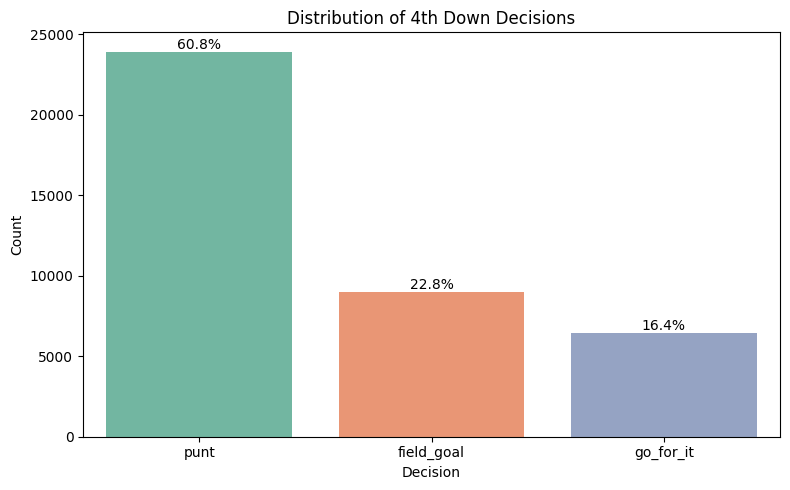

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


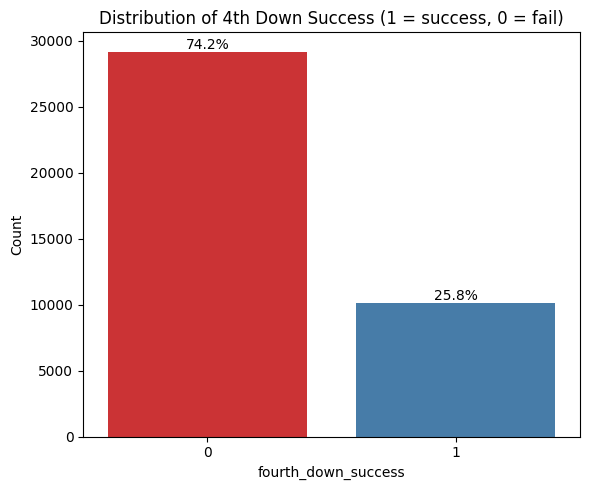

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


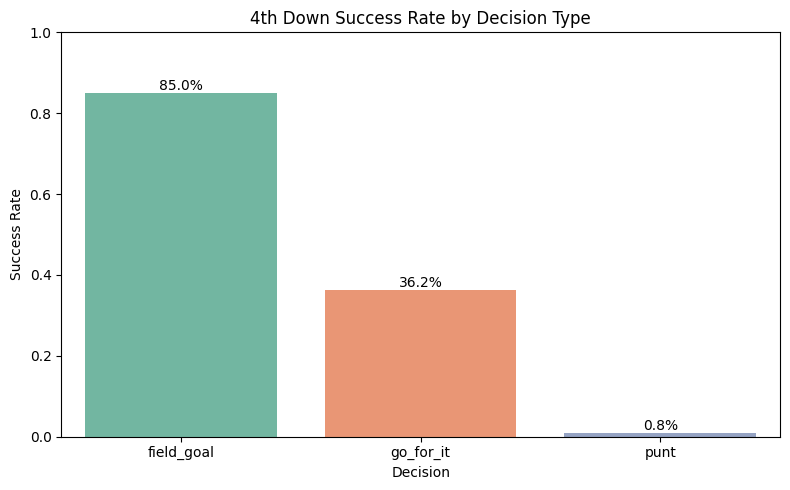

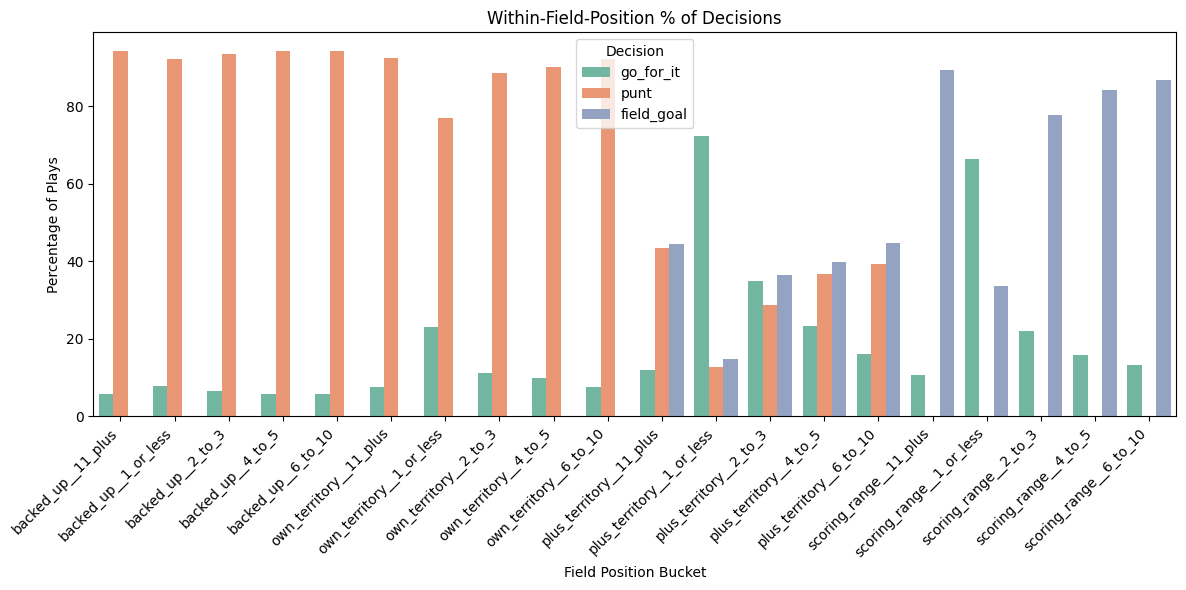

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


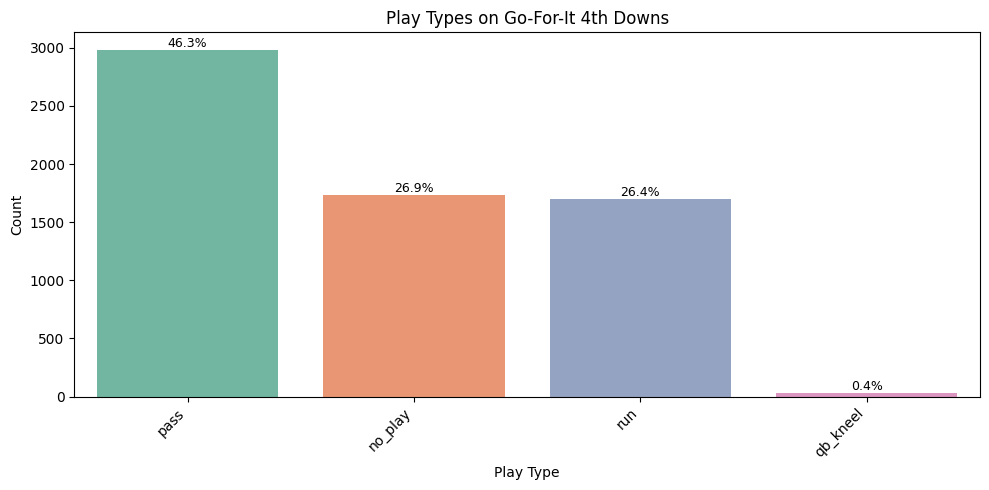

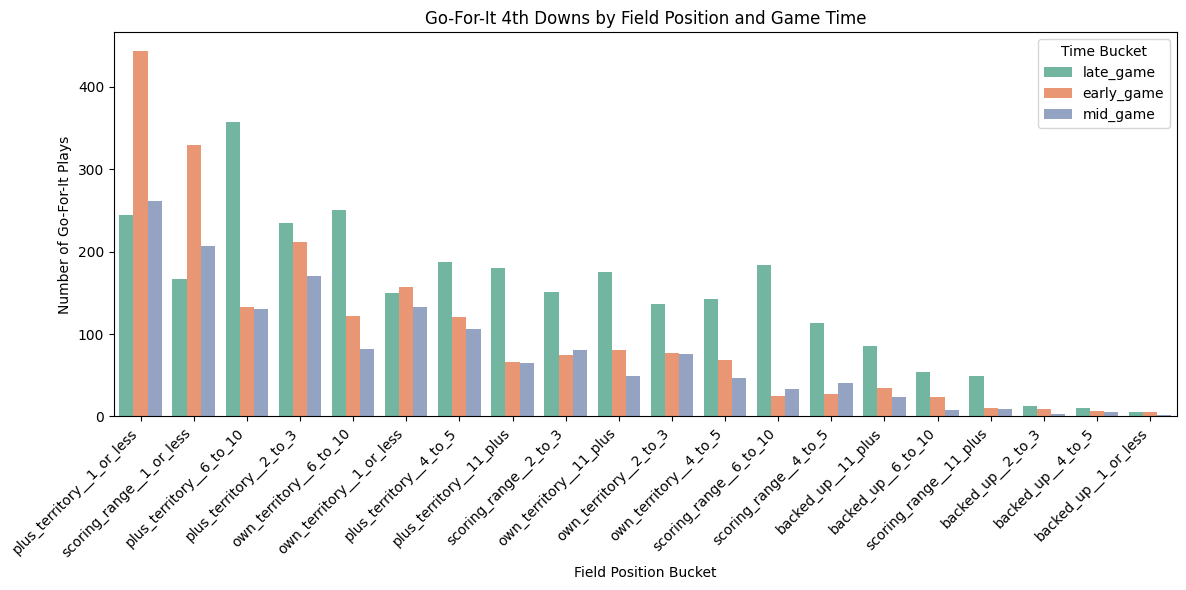

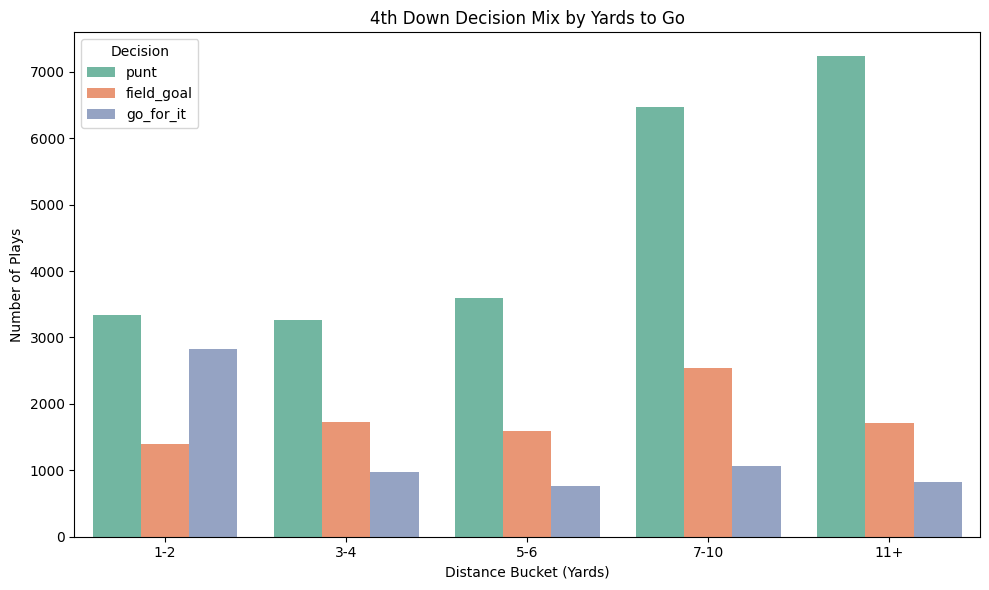

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:188: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


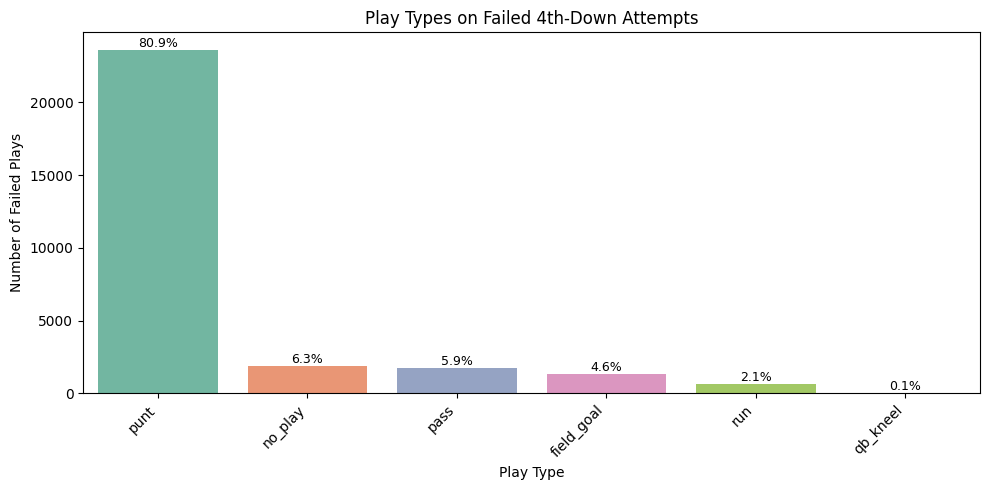

/var/folders/y2/97p_6_mn1ns3n6fh_thgm4780000gn/T/ipykernel_42286/3333674218.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


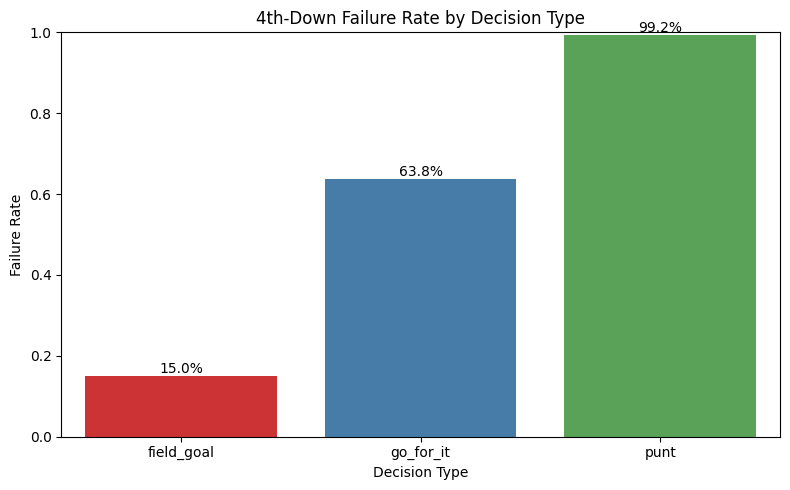

In [11]:

# 1) Distribution of decision_4th_class
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=feature_df,
    x="decision_4th_class",
    order=feature_df["decision_4th_class"].value_counts().index,
    palette="Set2"
)

total = len(feature_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Distribution of 4th Down Decisions")
ax.set_xlabel("Decision")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Distribution of fourth_down_success
plt.figure(figsize=(6, 5))
ax = sns.countplot(
    data=feature_df,
    x="fourth_down_success",
    palette="Set1"
)

total_success = len(feature_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_success
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("Distribution of 4th Down Success (1 = success, 0 = fail)")
ax.set_xlabel("fourth_down_success")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Success rate per decision class
succ_by_decision = (
    feature_df
    .groupby("decision_4th_class")["fourth_down_success"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=succ_by_decision,
    x="decision_4th_class",
    y="fourth_down_success",
    palette="Set2"
)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height*100:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center", va="bottom", fontsize=10
    )

ax.set_title("4th Down Success Rate by Decision Type")
ax.set_xlabel("Decision")
ax.set_ylabel("Success Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 4) Within-field-position percentage of decisions
counts = (
    feature_df
    .groupby(["field_position_bucket", "decision_4th_class"])
    .size()
    .reset_index(name="count")
)

counts["pct"] = (
    counts["count"] /
    counts.groupby("field_position_bucket")["count"].transform("sum")
    * 100
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=counts,
    x="field_position_bucket",
    y="pct",
    hue="decision_4th_class",
    palette="Set2"
)

ax.set_title("Within-Field-Position % of Decisions")
ax.set_xlabel("Field Position Bucket")
ax.set_ylabel("Percentage of Plays")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

# 5) Go-for-it subset
go_df = feature_df.query("decision_4th_class == 'go_for_it'").copy()

# a) play type when going for it
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=go_df,
    x="play_type_clean",
    order=go_df["play_type_clean"].value_counts().index,
    palette="Set2"
)

total_go = len(go_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_go
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Play Types on Go-For-It 4th Downs")
ax.set_xlabel("Play Type")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# b) go-for-it decisions by field position and time bucket
plt.figure(figsize=(12, 6))
ax = sns.countplot(
    data=go_df,
    x="field_position_bucket",
    hue="time_bucket",
    order=go_df["field_position_bucket"].value_counts().index,
    palette="Set2"
)

ax.set_title("Go-For-It 4th Downs by Field Position and Game Time")
ax.set_xlabel("Field Position Bucket")
ax.set_ylabel("Number of Go-For-It Plays")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Time Bucket")
plt.tight_layout()
plt.show()

# 6) Decision mix by yards to go
bins = [0, 2, 4, 6, 10, 100]
labels = ["1-2", "3-4", "5-6", "7-10", "11+"]
feature_df["distance_bucket"] = pd.cut(
    feature_df["ydstogo"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=feature_df,
    x="distance_bucket",
    hue="decision_4th_class",
    palette="Set2"
)

ax.set_title("4th Down Decision Mix by Yards to Go")
ax.set_xlabel("Distance Bucket (Yards)")
ax.set_ylabel("Number of Plays")
plt.tight_layout()
plt.legend(title="Decision")
plt.show()

# 7) Failed plays
failed_df = feature_df[feature_df["fourth_down_success"] == 0].copy()

plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=failed_df,
    x="play_type_clean",
    order=failed_df["play_type_clean"].value_counts().index,
    palette="Set2"
)

total_failed = len(failed_df)
for p in ax.patches:
    count = int(p.get_height())
    pct = 100 * count / total_failed
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom", fontsize=9
    )

ax.set_title("Play Types on Failed 4th-Down Attempts")
ax.set_xlabel("Play Type")
ax.set_ylabel("Number of Failed Plays")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 8) Failure rate by play type
by_play = (
    feature_df
    .groupby("play_type_clean")["fourth_down_success"]
    .agg(["count", "mean"])
    .reset_index()
    .rename(columns={"mean": "success_rate"})
)

by_play["failure_rate"] = 1 - by_play["success_rate"]

# Failure rate by decision type
failure_by_decision = (
    feature_df
    .groupby("decision_4th_class")["fourth_down_success"]
    .mean()
    .reset_index(name="success_rate")
)

failure_by_decision["failure_rate"] = 1 - failure_by_decision["success_rate"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=failure_by_decision,
    x="decision_4th_class",
    y="failure_rate",
    palette="Set1"
)

for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f"{h*100:.1f}%",
        (p.get_x() + p.get_width() / 2, h),
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("4th-Down Failure Rate by Decision Type")
ax.set_xlabel("Decision Type")
ax.set_ylabel("Failure Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


### 6. Key insights from EDA


Overall decision tendencies
Most coaches take a conservative approach: about 60.8% of 4th‑down situations result in a punt.

Roughly 22.8% result in a field goal attempt, and only about 16.4% are true “go for it” decisions.

Success vs. failure
Overall, about 74.2% of 4th‑down plays in the dataset are unsuccessful under your success definition (includes punts, failed conversions, and missed field goals).

The remaining 25.8% are successful 4th‑down outcomes.

Among successful 4th‑down plays, approximately 85% are made field goals, 36.2% are successful go‑for‑it attempts, and around 0.8% are successful outcomes following a punt (e.g., muffed return / turnover by the return team).

(If those three percentages come from separate conditional bases rather than “out of all successes,” you may want to reword them as separate bullets per decision type.)

Field position and yards to go
In their own territory, coaches overwhelmingly choose to punt on 4th down.

In opponent territory with 1 yard or less to go, there is a high frequency of go‑for‑it decisions.

With 2–3 yards to go in opponent territory, the relative frequencies of punting, attempting a field goal, and going for it become more similar (no single option dominates).

In the red zone, most coaches choose to attempt a field goal on 4th down rather than go for it.

By distance alone, most punts occur in 7+ yards‑to‑go situations, most field‑goal attempts occur with 7–10 yards to go, and most go‑for‑it attempts cluster in 1–2 yards to go.

Play types when going for it
When coaches go for it, the most common play type is a pass, accounting for about 46.3% of go‑for‑it attempts.

Game‑context patterns for “go for it”
The highest volume of go‑for‑it attempts occurs in early‑game situations where the offense is in opponent territory and has 1 or fewer yards to go.

The second‑highest cluster is late‑game, with the offense in opponent territory and 6–10 yards to go.

The third‑highest cluster is early‑game red‑zone situations with 1 or fewer yards to go.

Failure patterns
About 80.9% of failed 4th‑down plays are punts in your labeling schema (i.e., 4th‑down sequences that end in the ball being kicked away), followed next by “no play” sequences and then passes.

Approximately 63.8% of go‑for‑it attempts fail (i.e., do not result in a first down, touchdown, or made field goal under your success definition).




#### Next Steps

This notebook produces a clean modeling table and documents key descriptive patterns. 
The next step is to train a multiclass classifier (e.g., XGBoost) to predict punt vs. field goal vs. go-for-it from pre-snap features and evaluate its performance.